# Packages Needed

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Load and Name Datasets

In [5]:
countries = pd.read_csv("CountriesSD.csv")
summer = pd.read_csv("SummerSD.csv")
winter = pd.read_csv("WinterSD.csv")

#This was done on Google Colab which is we have commented out the os.path.join() function.

#countries = pd.read_csv(os.path.join("../content", "Datasets", "CountriesSD.csv"))
#summer = pd.read_csv(os.path.join("../content", "Datasets", "SummerSD.csv"))
#winter = pd.read_csv(os.path.join("../content", "Datasets", "WinterSD.csv"))

# Clean Datasets

In [ ]:
clean_countries = countries.dropna()
clean_countries

,Unnamed: 0,Country,Code,Population,GDP per Capita
0,0,Afghanistan,AFG,32526562.0,594.323081
1,1,Albania,ALB,2889167.0,3945.217582
2,2,Algeria,ALG,39666519.0,4206.031232
5,5,Angola,ANG,25021974.0,4101.472152
6,6,Antigua and Barbuda,ANT,91818.0,13714.731962
...,...,...,...,...,...
194,194,Vanuatu,VAN,264652.0,2805.314644
196,196,Vietnam,VIE,91703800.0,2111.138024
198,198,Yemen,YEM,26832215.0,1406.291651
199,199,Zambia,ZAM,16211767.0,1304.879014


In [ ]:
clean_summer = summer.dropna()
clean_summer

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
0,0,1896,Athens,Aquatics,Swimming,Alfred Hajos,HUN,Men,100M Freestyle,Gold,Hungary
1,1,1896,Athens,Aquatics,Swimming,Otto Herschmann,AUT,Men,100M Freestyle,Silver,Austria
2,2,1896,Athens,Aquatics,Swimming,Dimitrios Drivas,GRE,Men,100M Freestyle For Sailors,Bronze,Greece
3,3,1896,Athens,Aquatics,Swimming,Ioannis Malokinis,GRE,Men,100M Freestyle For Sailors,Gold,Greece
4,4,1896,Athens,Aquatics,Swimming,Spiridon Chasapis,GRE,Men,100M Freestyle For Sailors,Silver,Greece
...,...,...,...,...,...,...,...,...,...,...,...
31160,31160,2012,London,Wrestling,Wrestling Freestyle,Damian Janikowski,POL,Men,Wg 84 KG,Bronze,Poland
31161,31161,2012,London,Wrestling,Wrestling Freestyle,Ghasem Gholamreza Rezaei,IRI,Men,Wg 96 KG,Gold,Iran
31162,31162,2012,London,Wrestling,Wrestling Freestyle,Rustam Totrov,RUS,Men,Wg 96 KG,Silver,Russia
31163,31163,2012,London,Wrestling,Wrestling Freestyle,Artur Aleksanyan,ARM,Men,Wg 96 KG,Bronze,Armenia


In [ ]:
clean_winter = winter.dropna()
clean_winter

,Unnamed: 0,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,0,1924,Chamonix,Biathlon,Biathlon,"BERTHET, G.",FRA,Men,Military Patrol,Bronze
1,1,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, C.",FRA,Men,Military Patrol,Bronze
2,2,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, Maurice",FRA,Men,Military Patrol,Bronze
3,3,1924,Chamonix,Biathlon,Biathlon,"VANDELLE, André",FRA,Men,Military Patrol,Bronze
4,4,1924,Chamonix,Biathlon,Biathlon,"AUFDENBLATTEN, Adolf",SUI,Men,Military Patrol,Gold
...,...,...,...,...,...,...,...,...,...,...
5765,5765,2014,Sochi,Skiing,Snowboard,"JONES, Jenny",GBR,Women,Slopestyle,Bronze
5766,5766,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold
5767,5767,2014,Sochi,Skiing,Snowboard,"MALTAIS, Dominique",CAN,Women,Snowboard Cross,Silver
5768,5768,2014,Sochi,Skiing,Snowboard,"SAMKOVA, Eva",CZE,Women,Snowboard Cross,Gold


# Step 3: EDA of Total Medal Distribution of the Top 10 Countries (Summer vs Winter)

In [ ]:
medal_count_summer = (clean_summer.groupby("Country").size().sort_values(ascending = False).head(10))
medal_count_summer

,0
Country,
United States,4585
United Kingdom,1720
France,1396
Germany,1305
Italy,1296
Australia,1189
Hungary,1079
Sweden,1044
Netherlands,851


Text(0.5, 1.0, 'Top 10 Countries with Most Olympic Medals (Summer)')

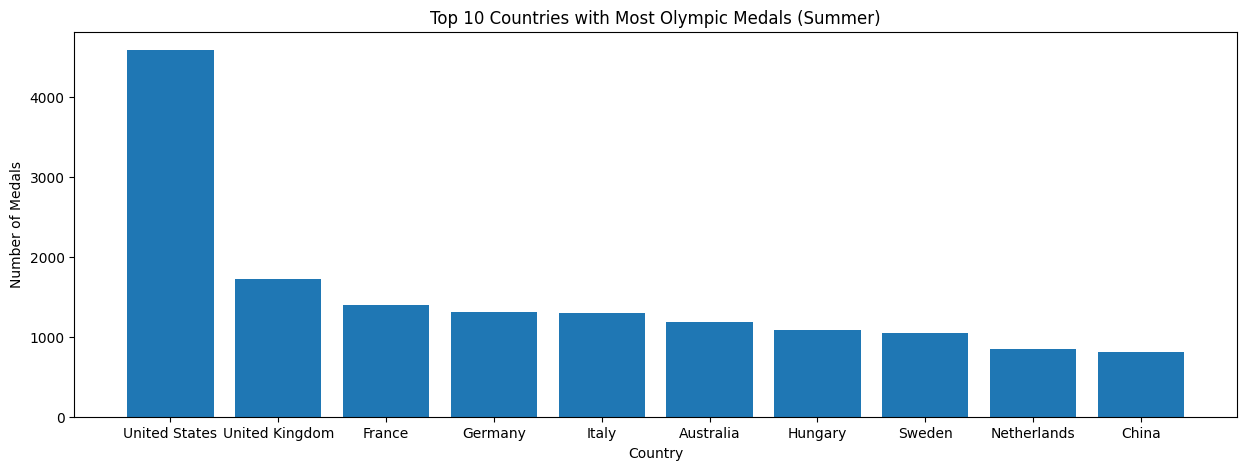

In [ ]:
plt.figure(figsize = (15, 5))
plt.bar(medal_count_summer.index, medal_count_summer.values)
plt.xlabel("Country")
plt.ylabel("Number of Medals")
plt.title("Top 10 Countries with Most Olympic Medals (Summer)")

In [ ]:
medal_count_winter = (clean_winter.groupby("Country").size().sort_values(ascending = False).head(10))
medal_count_winter

,0
Country,
USA,653
CAN,625
NOR,457
URS,440
FIN,434
SWE,433
GER,360
SUI,285
AUT,280


Text(0.5, 1.0, 'Top 10 Countries with Most Olympic Medals (Winter)')

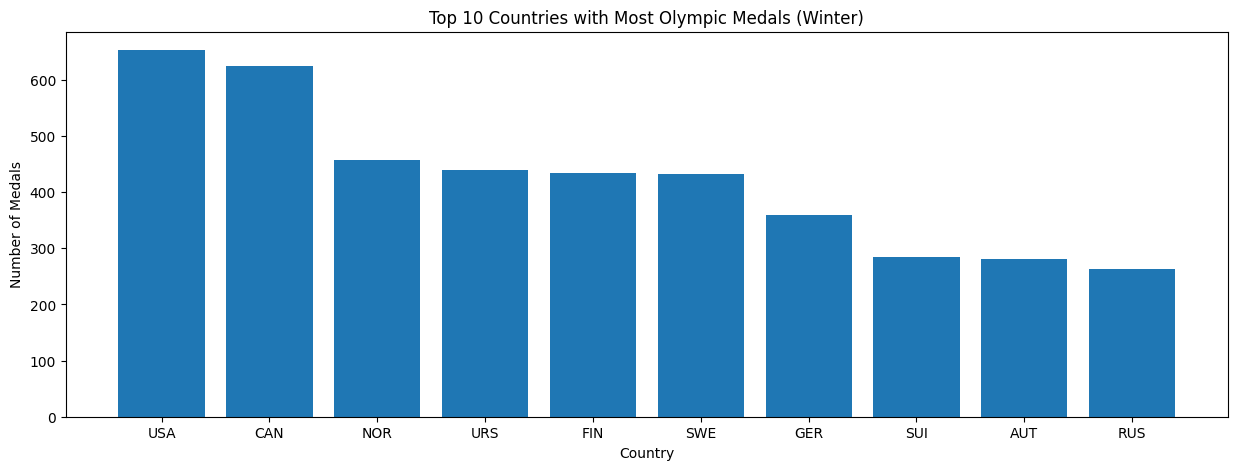

In [ ]:
plt.figure(figsize = (15, 5))
plt.bar(medal_count_winter.index, medal_count_winter.values)
plt.xlabel("Country")
plt.ylabel("Number of Medals")
plt.title("Top 10 Countries with Most Olympic Medals (Winter)")

# Step 3: EDA of Top 5 Medal Countries Changes Over Time (Summer vs Winter)

In [ ]:
top_5_summer = (clean_summer.groupby("Country").size().sort_values(ascending = False).head(5))
top_5_summer

,0
Country,
United States,4585
United Kingdom,1720
France,1396
Germany,1305
Italy,1296


In [ ]:
top_5_countries_over_time_summer = clean_summer[clean_summer["Country"].isin(top_5_summer.index)].groupby(["Year", "Country"]).size().unstack(fill_value = 0)
top_5_countries_over_time_summer

Country,France,Germany,Italy,United Kingdom,United States
Year,,,,,
1896,11,33,0,7,20
1900,185,40,4,78,55
1904,0,13,0,2,394
1908,35,22,7,347,63
1912,25,52,21,160,101
1920,141,0,84,107,193
1924,122,0,51,66,198
1928,36,72,70,55,84
1932,37,38,77,34,181


Text(0.5, 1.0, 'Top 5 Countries with Most Olympic Medals, Changes Over Time (Summer)')

<Figure size 5000x5000 with 0 Axes>

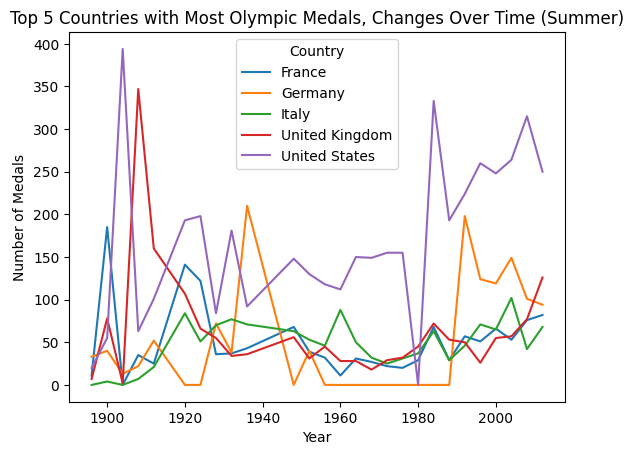

In [ ]:
plt.figure(figsize = (50, 50))
top_5_countries_over_time_summer.plot()
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.title("Top 5 Countries with Most Olympic Medals, Changes Over Time (Summer)")

In [ ]:
top_5_winter = (clean_winter.groupby("Country").size().sort_values(ascending = False).head(5))
top_5_winter

,0
Country,
USA,653
CAN,625
NOR,457
URS,440
FIN,434


In [ ]:
top_5_countries_over_time_winter = clean_winter[clean_winter["Country"].isin(top_5_winter.index)].groupby(["Year", "Country"]).size().unstack(fill_value = 0)
top_5_countries_over_time_winter

Country,CAN,FIN,NOR,URS,USA
Year,,,,,
1924,9,15,17,0,13
1928,12,4,15,0,14
1932,20,3,10,0,45
1936,13,9,18,0,16
1948,20,9,13,0,16
1952,17,12,19,0,30
1956,20,12,4,37,26
1960,21,13,9,42,27
1964,7,15,15,46,8


Text(0.5, 1.0, 'Top 5 Countries with Most Olympic Medals, Changes Over Time (Winter)')

<Figure size 5000x5000 with 0 Axes>

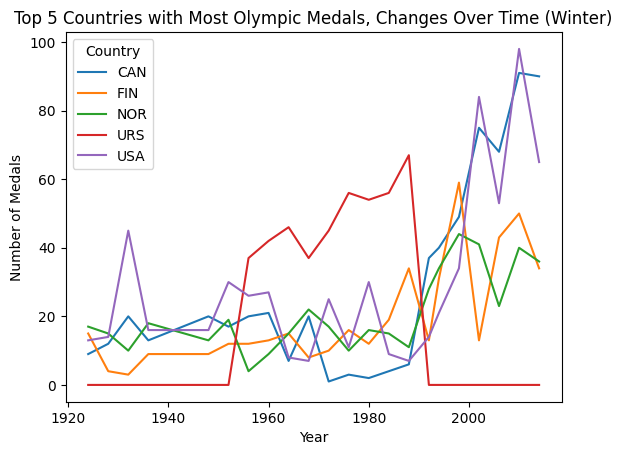

In [ ]:
plt.figure(figsize = (50, 50))
top_5_countries_over_time_winter.plot()
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.title("Top 5 Countries with Most Olympic Medals, Changes Over Time (Winter)")

# Step 5: EDA of Total Medal Counts by Gender Over Time (Summer vs Winter)

In [ ]:
gender_medal_summer = (clean_summer.groupby(["Year", "Gender"]).size().unstack())
gender_medal_summer

Gender,Men,Women
Year,,
1896,145.0,NaN
1900,469.0,7.0
1904,450.0,12.0
1908,762.0,15.0
1912,833.0,28.0
1920,1246.0,42.0
1924,798.0,51.0
1928,587.0,95.0
1932,551.0,60.0


Text(0.5, 1.0, 'Medal Counts by Gender Over Time (Summer)')

<Figure size 1500x500 with 0 Axes>

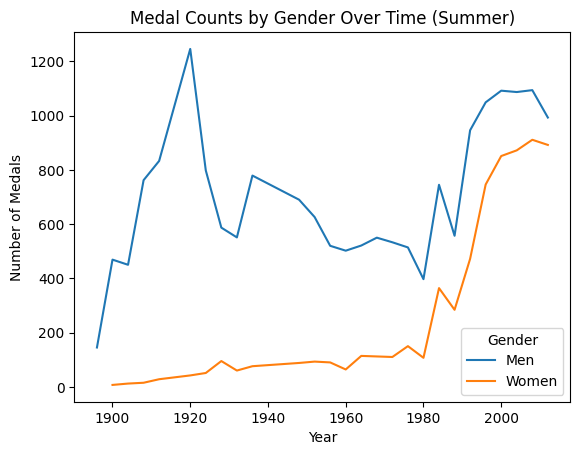

In [ ]:
plt.figure(figsize = (15, 5))
gender_medal_summer.plot()
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.title("Medal Counts by Gender Over Time (Summer)")

In [ ]:
gender_medal_winter = (clean_winter.groupby(["Year", "Gender"]).size().unstack())
gender_medal_winter

Gender,Men,Women
Year,,
1924,112,6
1928,83,6
1932,110,6
1936,99,9
1948,125,15
1952,118,18
1956,123,27
1960,108,39
1964,139,46


Text(0.5, 1.0, 'Medal Counts by Gender Over Time (Winter)')

<Figure size 1500x500 with 0 Axes>

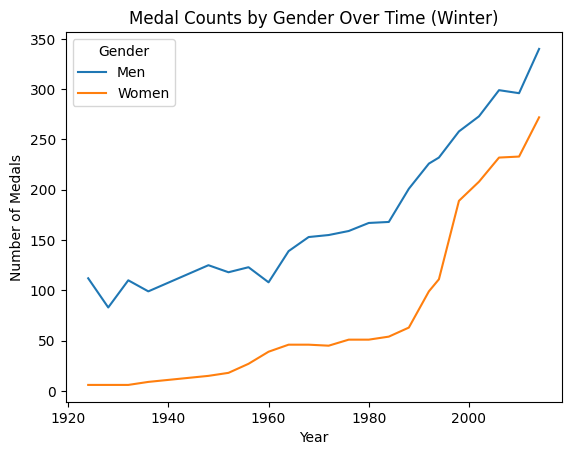

In [ ]:
plt.figure(figsize = (15, 5))
gender_medal_winter.plot()
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.title("Medal Counts by Gender Over Time (Winter)")

# Step 5: EDA of Total Medal Counts by Gender (Summer & Winter)

In [ ]:
gender_total_summer = clean_summer["Gender"].value_counts()
gender_total_summer

,count
Gender,
Men,19036
Women,6706


Text(0.5, 1.0, 'Total Medal Counts by Gender (Summer)')

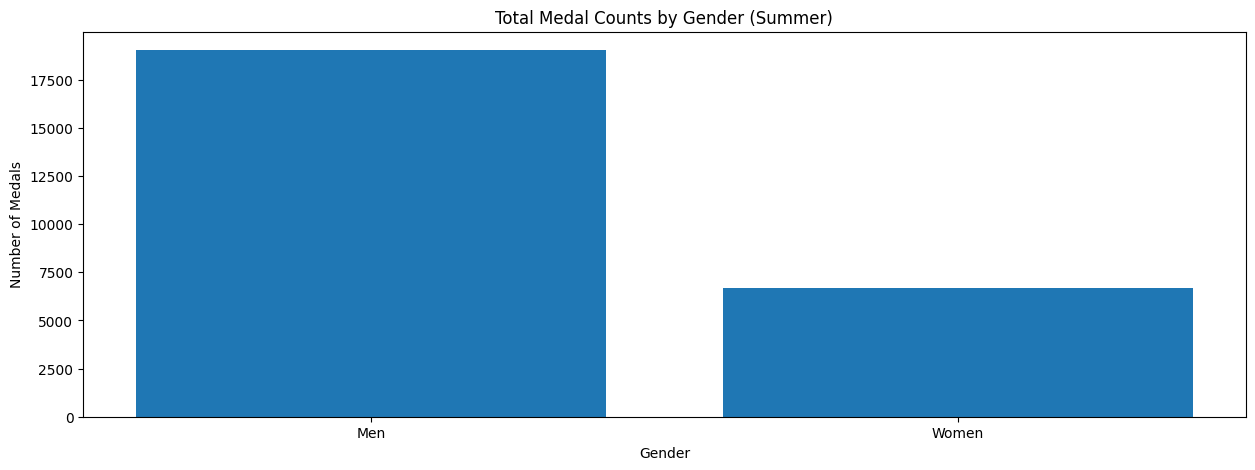

In [ ]:
plt.figure(figsize = (15, 5))
plt.bar(gender_total_summer.index, gender_total_summer.values)
plt.xlabel("Gender")
plt.ylabel("Number of Medals")
plt.title("Total Medal Counts by Gender (Summer)")

In [ ]:
gender_total_winter = clean_winter["Gender"].value_counts()
gender_total_winter

,count
Gender,
Men,3944
Women,1826


Text(0.5, 1.0, 'Total Medal Counts by Gender (Winter)')

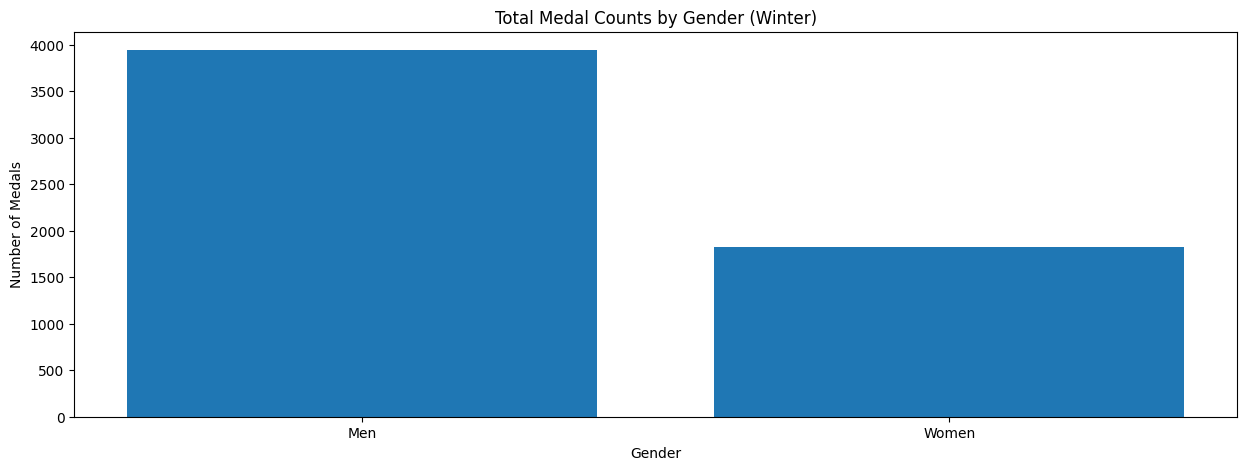

In [138]:
plt.figure(figsize = (15, 5))
plt.bar(gender_total_winter.index, gender_total_winter.values)
plt.xlabel("Gender")
plt.ylabel("Number of Medals")
plt.title("Total Medal Counts by Gender (Winter)")